## Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

### Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

### Теоретическое введение (обязательно к прочтению)

#### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

#### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

#### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

### Часть 1. Исследование многомерного нормального распределения (10 баллов)

#### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

#### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

### Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

### Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

#### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

#### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

### Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

#### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

#### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

#### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

### Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

#### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

#### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

#### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

### Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

#### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

#### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

#### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

### Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

### Полезные функции и материалы

#### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

#### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

### Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

from sklearn.base import BaseEstimator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)

## Часть 1

In [3]:
# Параметры
M = 500
sigma1 = 0.3
sigma2 = 0.8
alpha = np.deg2rad(30)

# Матрица поворота
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

# Два независимых вектора
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)
X_ind = np.column_stack([x1, x2])

# Применяем поворот
X = X_ind @ R.T

# Выборочная ковариация
C_sample = np.cov(X.T)

# Теоретическая ковариация
C_theor = R @ np.diag([sigma1**2, sigma2**2]) @ R.T

print("Выборочная ковариационная матрица:\n", C_sample)
print("\nТеоретическая ковариационная матрица:\n", C_theor)

# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"

Выборочная ковариационная матрица:
 [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]

Теоретическая ковариационная матрица:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


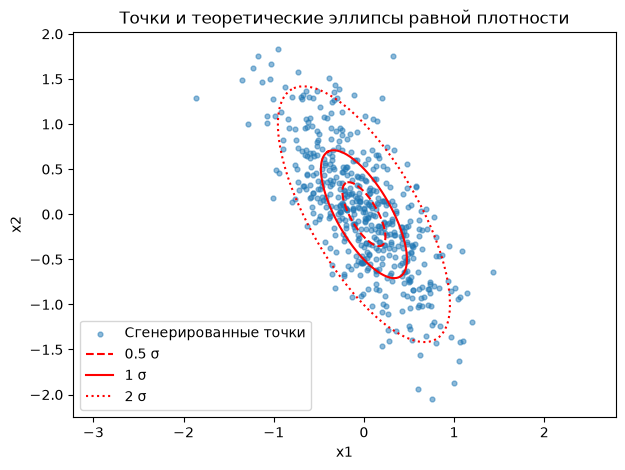

In [4]:
def plot_ellipse(mean, cov, ax, nsig=1, **kwargs):
    """Рисует эллипс равной плотности для многомерного нормального распределения."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.linspace(0, 2 * np.pi, 300)
    circle = np.array([np.cos(theta), np.sin(theta)])
    ell = vecs @ np.diag(np.sqrt(vals)) @ circle * nsig
    ax.plot(mean[0] + ell[0], mean[1] + ell[1], **kwargs)

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.5, label="Сгенерированные точки")

mean_theor = np.zeros(2)
for nsig, style in zip([0.5, 1, 2], ["--", "-", ":"]):
    plot_ellipse(mean_theor, C_theor, ax, nsig=nsig,
                 color="red", linestyle=style, label=f"{nsig} σ")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Точки и теоретические эллипсы равной плотности")
ax.legend()
ax.axis("equal")
plt.show()

### Вывод по 1.1:
Выборочная матрица ковариации близка к теоретической. Поворот действительно создаёт корреляцию между признаками, которой не было в исходных независимых координатах.

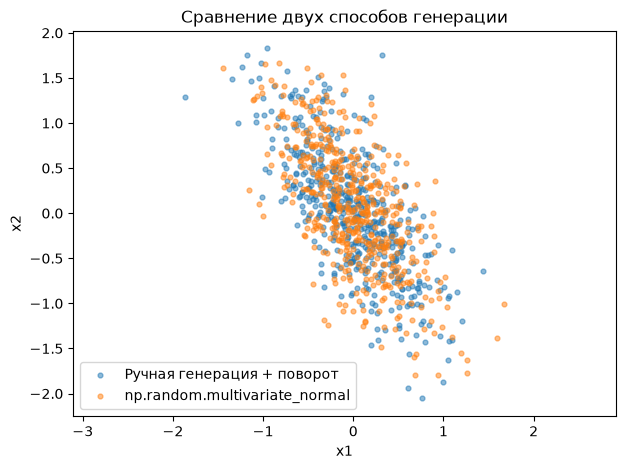

In [5]:
X_mvn = np.random.multivariate_normal(mean=[0, 0], cov=C_theor, size=M)

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.5, label="Ручная генерация + поворот")
ax.scatter(X_mvn[:, 0], X_mvn[:, 1], s=12, alpha=0.5, label="np.random.multivariate_normal")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Сравнение двух способов генерации")
ax.legend()
ax.axis("equal")
plt.show()

### Ответ на вопрос 1.2:
Да, облака точек визуально совпадают. Встроенная функция np.random.multivariate_normal предпочтительнее, потому что она напрямую генерирует выборку из многомерного нормального распределения с заданными средним и ковариационной матрицей. Не нужно вручную делать поворот, следить за порядком умножения матриц и отдельно пересчитывать теоретическую ковариацию. Кроме того, встроенная функция устойчивее работает в многомерном случае и автоматически проверяет корректность ковариационной матрицы.

## Часть 2

In [6]:
# Оценки по данным из 1.1
mu_hat = np.mean(X, axis=0)
C_hat = np.cov(X.T)

print("Оценка среднего:", mu_hat)
print("Оценка ковариации:\n", C_hat)

# Сетка точек
x_grid = np.linspace(-2, 2, 120)
y_grid = np.linspace(-2, 2, 120)
XX, YY = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([XX.ravel(), YY.ravel()])

# Способ 1: scipy
m = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = m.pdf(grid_points).reshape(XX.shape)

# Способ 2: ручное вычисление
d = 2
det_C = np.linalg.det(C_hat)
inv_C = np.linalg.inv(C_hat)
diff = grid_points - mu_hat
exponent = -0.5 * np.sum(diff @ inv_C * diff, axis=1)
coef = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_C))
pdf_manual = (coef * np.exp(exponent)).reshape(XX.shape)

# Проверка
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print("Максимальная разница между ручным и scipy вычислением:", max_diff)
assert max_diff < 1e-10, "Ручное вычисление отличается от scipy"
print("Автопроверка 2 пройдена.")

Оценка среднего: [-0.01095388  0.02307548]
Оценка ковариации:
 [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Максимальная разница между ручным и scipy вычислением: 2.7755575615628914e-16
Автопроверка 2 пройдена.


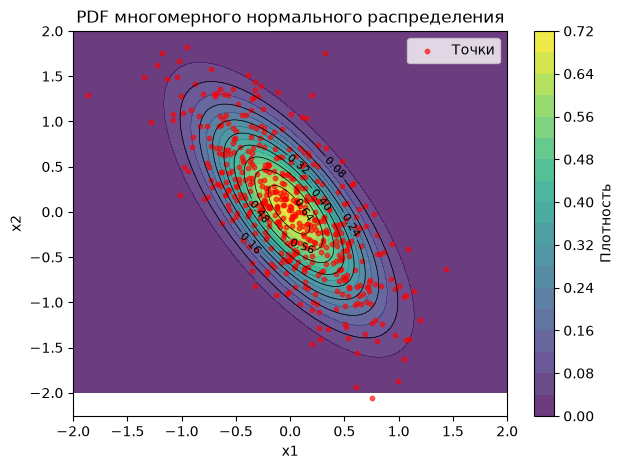

In [7]:
fig, ax = plt.subplots()
cf = ax.contourf(XX, YY, pdf_scipy, levels=20, cmap="viridis", alpha=0.8)
cs = ax.contour(XX, YY, pdf_scipy, levels=8, colors="black", linewidths=0.5)
ax.clabel(cs, inline=True, fontsize=8)
ax.scatter(X[:, 0], X[:, 1], s=10, color="red", alpha=0.6, label="Точки")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("PDF многомерного нормального распределения")
ax.legend()
plt.colorbar(cf, ax=ax, label="Плотность")
plt.show()

### Вывод по части 2:
Ручная формула полностью совпала с scipy.stats.multivariate_normal.pdf. Это подтверждает, что мы правильно реализовали плотность многомерного нормального распределения через определитель и обратную матрицу ковариации.

## Часть 3

In [8]:
n = 300
mu0 = np.array([-0.5, 0.5])
C0 = np.array([[0.2, 0.1],
               [0.1, 0.3]])

mu1 = np.array([0.5, -0.5])
C1 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])

X0 = np.random.multivariate_normal(mu0, C0, n)
X1 = np.random.multivariate_normal(mu1, C1, n)

X_bin = np.vstack([X0, X1])
y_bin = np.hstack([np.zeros(n), np.ones(n)])

print("Размер X:", X_bin.shape)
print("Размер y:", y_bin.shape)

Размер X: (600, 2)
Размер y: (600,)


p(y=0) = 0.500, p(y=1) = 0.500


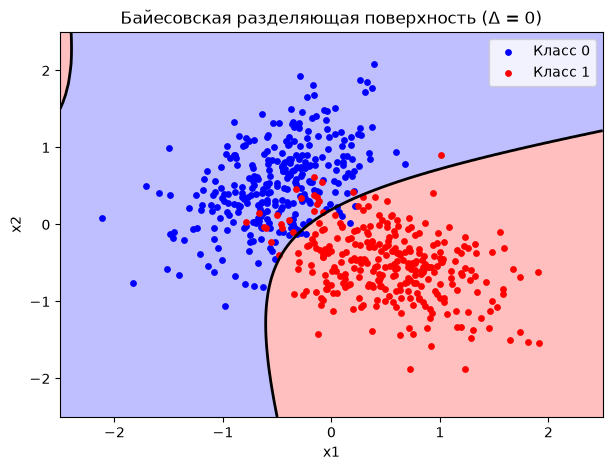

In [9]:
# Оценка априорных вероятностей
prior0 = np.mean(y_bin == 0)
prior1 = np.mean(y_bin == 1)
print(f"p(y=0) = {prior0:.3f}, p(y=1) = {prior1:.3f}")

# Сетка
x_grid = np.linspace(-2.5, 2.5, 200)
y_grid = np.linspace(-2.5, 2.5, 200)
XX, YY = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([XX.ravel(), YY.ravel()])

# Правдоподобия
pdf0 = multivariate_normal(mean=mu0, cov=C0).pdf(grid_points)
pdf1 = multivariate_normal(mean=mu1, cov=C1).pdf(grid_points)

# Delta = p(x|0)p(0) - p(x|1)p(1)
Delta = (pdf0 * prior0 - pdf1 * prior1).reshape(XX.shape)

fig, ax = plt.subplots()
# Фон: положительные значения — класс 0 (синий), отрицательные — класс 1 (красный)
ax.contourf(XX, YY, Delta, levels=[-np.inf, 0, np.inf],
            colors=["red", "blue"], alpha=0.25)
# Разделяющая линия Delta = 0
ax.contour(XX, YY, Delta, levels=[0], colors="black", linewidths=2)

ax.scatter(X0[:, 0], X0[:, 1], s=15, color="blue", label="Класс 0")
ax.scatter(X1[:, 0], X1[:, 1], s=15, color="red", label="Класс 1")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Байесовская разделяющая поверхность (Δ = 0)")
ax.legend()
plt.show()

### Ответ на вопрос 3.2:
Разделяющая поверхность не является линейной. В данном случае ковариационные матрицы классов разные: C0 != C1. В общем байесовском классификаторе с нормальными правдоподобиями граница определяется квадратичной формой, поэтому получается кривая второго порядка (эллипс, гипербола или парабола). Линейной она стала бы только при C0 = C1, то есть в случае LDA.

## Часть 4

### 4.1 Теоретический вывод

-

In [10]:
class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.priors_ = None     # dict {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.means_ = {}
        self.priors_ = {}
        scatter = np.zeros((n_features, n_features))

        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = np.mean(Xc, axis=0)
            self.priors_[c] = len(Xc) / n_samples
            centered = Xc - self.means_[c]
            scatter += centered.T @ centered

        # Общая (pooled) ковариация
        self.cov_ = scatter / (n_samples - len(self.classes_))
        # Регуляризация для устойчивости
        self.cov_ += 1e-6 * np.eye(n_features)

        if len(self.classes_) == 2:
            c0, c1 = self.classes_[0], self.classes_[1]
            mu0, mu1 = self.means_[c0], self.means_[c1]
            inv_cov = np.linalg.inv(self.cov_)

            self.coef_ = inv_cov @ (mu1 - mu0)
            self.intercept_ = (
                -0.5 * mu1 @ inv_cov @ mu1
                + 0.5 * mu0 @ inv_cov @ mu0
                + np.log(self.priors_[c1] / self.priors_[c0])
            )
        else:
            raise NotImplementedError("MyLDA реализован для бинарной классификации.")

        return self

    def predict(self, X):
        X = np.asarray(X)
        scores = X @ self.coef_ + self.intercept_
        return np.where(scores > 0, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        X = np.asarray(X)
        log_probs = []
        for c in self.classes_:
            log_prior = np.log(self.priors_[c])
            log_lik = multivariate_normal(mean=self.means_[c], cov=self.cov_).logpdf(X)
            log_probs.append(log_prior + log_lik)
        log_probs = np.array(log_probs).T
        log_probs -= np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= np.sum(probs, axis=1, keepdims=True)
        return probs

In [11]:
# Генерируем два класса с одинаковой ковариацией
np.random.seed(0)
C = np.array([[1.0, 0.5],
              [0.5, 1.0]])
mu0 = np.array([0.0, 0.0])
mu1 = np.array([2.0, 2.0])

X0 = np.random.multivariate_normal(mu0, C, 200)
X1 = np.random.multivariate_normal(mu1, C, 200)

X_train = np.vstack([X0[:150], X1[:150]])
y_train = np.hstack([np.zeros(150), np.ones(150)])
X_test = np.vstack([X0[150:], X1[150:]])
y_test = np.hstack([np.zeros(50), np.ones(50)])

# Обучаем свои и sklearn-модели
my_lda = MyLDA().fit(X_train, y_train)
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

print("Мой coef_:", my_lda.coef_)
print("sklearn coef_:", sk_lda.coef_.ravel())
print("Мой intercept_:", my_lda.intercept_)
print("sklearn intercept_:", sk_lda.intercept_)

# Проверки
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.allclose(my_lda.coef_, sk_lda.coef_.ravel(), atol=1e-5), "Вектора весов не совпадают"
assert np.allclose(my_lda.intercept_, sk_lda.intercept_, atol=1e-5), "Пороги не совпадают"
print("Автопроверка 4.3 пройдена.")

Мой coef_: [1.53950285 1.24072137]
sklearn coef_: [1.53950404 1.24072203]
Мой intercept_: -2.979282976283973
sklearn intercept_: [-2.97928496]
Автопроверка 4.3 пройдена.


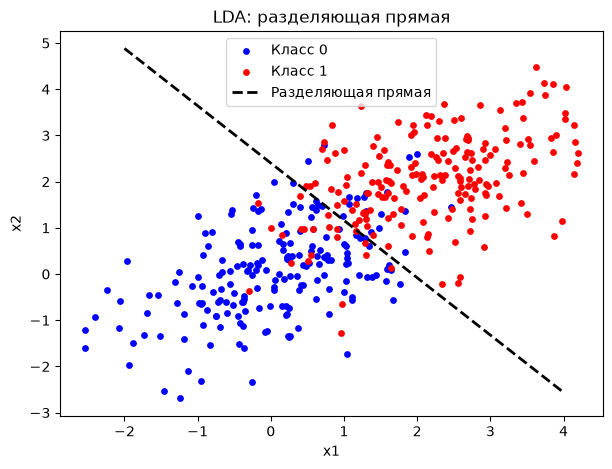

In [12]:
fig, ax = plt.subplots()
ax.scatter(X0[:, 0], X0[:, 1], s=15, color="blue", label="Класс 0")
ax.scatter(X1[:, 0], X1[:, 1], s=15, color="red", label="Класс 1")

# Строим прямую w^T x + b = 0
x_vals = np.linspace(-2, 4, 100)
# w0*x + w1*y + b = 0  =>  y = (-w0*x - b) / w1
w0, w1 = my_lda.coef_
b = my_lda.intercept_
y_vals = (-w0 * x_vals - b) / w1

ax.plot(x_vals, y_vals, "k--", linewidth=2, label="Разделяющая прямая")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("LDA: разделяющая прямая")
ax.legend()
plt.show()

### Вывод по части 4:
Реализованный MyLDA совпадает с sklearn.discriminant_analysis.LinearDiscriminantAnalysis по предсказаниям, коэффициентам и порогу. Это подтверждает корректность вывода и реализации.

## Часть 5

### 5.1 Теоретическое обоснование
-

In [13]:
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector}
        self.priors_ = None     # dict {class: prior_prob}

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = np.mean(Xc, axis=0)
            self.vars_[c] = np.var(Xc, axis=0) + 1e-9  # сглаживание
            self.priors_[c] = len(Xc) / n_samples

        return self

    def _log_likelihood(self, X, c):
        mu = self.means_[c]
        var = self.vars_[c]
        return -0.5 * np.sum(
            np.log(2 * np.pi * var) + ((X - mu) ** 2) / var,
            axis=1
        )

    def predict(self, X):
        X = np.asarray(X)
        log_probs = []
        for c in self.classes_:
            log_prior = np.log(self.priors_[c])
            log_lik = self._log_likelihood(X, c)
            log_probs.append(log_prior + log_lik)
        log_probs = np.array(log_probs).T
        return self.classes_[np.argmax(log_probs, axis=1)]

    def predict_proba(self, X):
        X = np.asarray(X)
        log_probs = []
        for c in self.classes_:
            log_prior = np.log(self.priors_[c])
            log_lik = self._log_likelihood(X, c)
            log_probs.append(log_prior + log_lik)
        log_probs = np.array(log_probs).T
        log_probs -= np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= np.sum(probs, axis=1, keepdims=True)
        return probs

In [14]:
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)

print("Предсказания MyNB:     ", my_nb.predict(X_test)[:20])
print("Предсказания GaussianNB:", sk_nb.predict(X_test)[:20])

assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
print("Автопроверка 5.3 пройдена.")

Предсказания MyNB:      [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
Предсказания GaussianNB: [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
Автопроверка 5.3 пройдена.


### Вывод по части 5:
MyNB полностью совпадает с GaussianNB по предсказаниям. Использование логарифмического правдоподобия позволило избежать численного переполнения и сделать вычисления устойчивыми.

## Часть 6

In [15]:
def get_dataset_A():
    """LDA-оптимальный: классы имеют одинаковую ковариацию, но разные средние."""
    return make_classification(
        n_samples=1000,
        n_features=10,
        n_informative=5,
        n_redundant=2,
        n_classes=2,
        n_clusters_per_class=1,
        class_sep=2.0,
        flip_y=0.01,
        random_state=42
    )

def get_dataset_B():
    """
    NB-оптимальный: признаки независимы внутри каждого класса,
    но ковариации классов разные (разные дисперсии).
    """
    np.random.seed(43)
    n_samples = 500
    n_features = 10

    # Класс 0: независимые признаки, дисперсия 1
    X0 = np.random.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    # Класс 1: независимые признаки, другое среднее и дисперсия 1.5
    X1 = np.random.normal(loc=0.8, scale=1.5, size=(n_samples, n_features))

    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])
    return X, y

def get_dataset_C():
    """Сложный: признаки коррелированы, ковариации классов разные, есть шум."""
    return make_classification(
        n_samples=1000,
        n_features=10,
        n_informative=5,
        n_redundant=2,
        n_classes=2,
        n_clusters_per_class=1,
        class_sep=1.0,
        flip_y=0.05,
        random_state=44
    )

datasets = {
    "A (LDA-оптимальный)": get_dataset_A(),
    "B (NB-оптимальный)": get_dataset_B(),
    "C (сложный)": get_dataset_C()
}

for name, (X, y) in datasets.items():
    print(f"{name}: X.shape = {X.shape}, y.shape = {y.shape}")

A (LDA-оптимальный): X.shape = (1000, 10), y.shape = (1000,)
B (NB-оптимальный): X.shape = (1000, 10), y.shape = (1000,)
C (сложный): X.shape = (1000, 10), y.shape = (1000,)


Датасет: A (LDA-оптимальный)

--- MyLDA на датасете A (LDA-оптимальный) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200



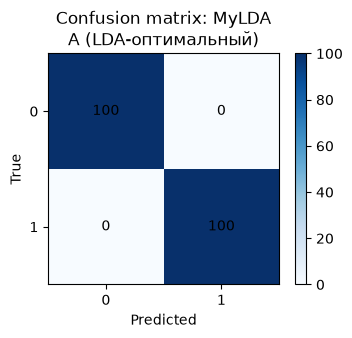


--- MyNB на датасете A (LDA-оптимальный) ---
              precision    recall  f1-score   support

           0     0.9804    1.0000    0.9901       100
           1     1.0000    0.9800    0.9899       100

    accuracy                         0.9900       200
   macro avg     0.9902    0.9900    0.9900       200
weighted avg     0.9902    0.9900    0.9900       200



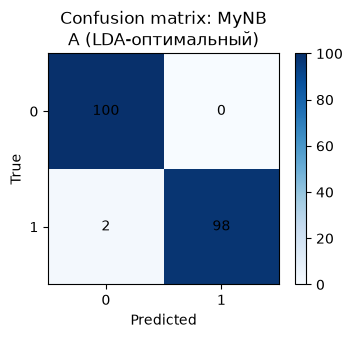


--- LogisticRegression на датасете A (LDA-оптимальный) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200



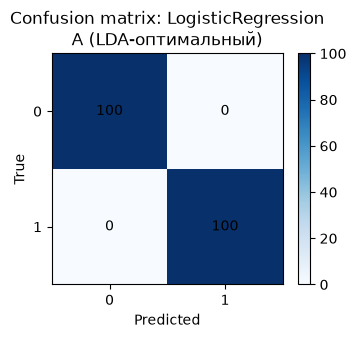

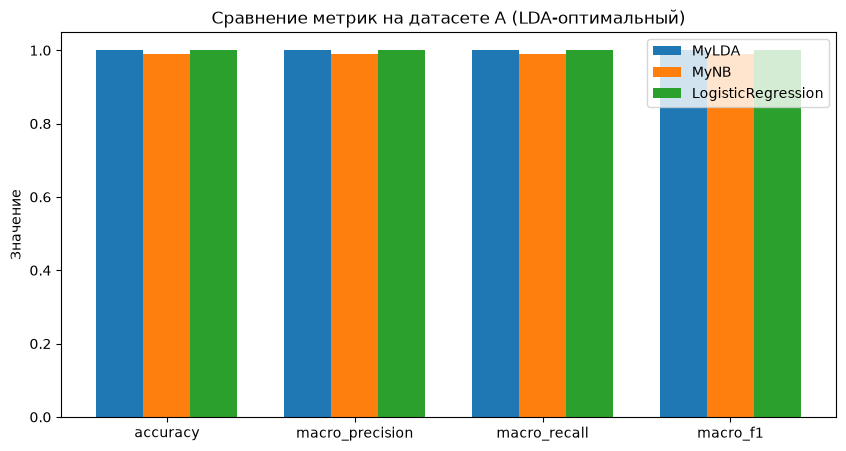

Датасет: B (NB-оптимальный)

--- MyLDA на датасете B (NB-оптимальный) ---
              precision    recall  f1-score   support

         0.0     0.8762    0.9200    0.8976       100
         1.0     0.9158    0.8700    0.8923       100

    accuracy                         0.8950       200
   macro avg     0.8960    0.8950    0.8949       200
weighted avg     0.8960    0.8950    0.8949       200



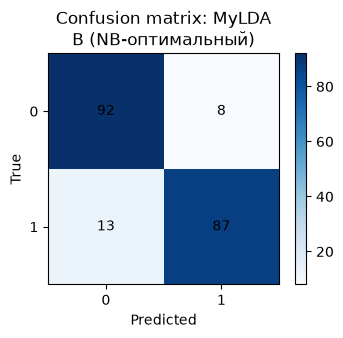


--- MyNB на датасете B (NB-оптимальный) ---
              precision    recall  f1-score   support

         0.0     0.9468    0.8900    0.9175       100
         1.0     0.8962    0.9500    0.9223       100

    accuracy                         0.9200       200
   macro avg     0.9215    0.9200    0.9199       200
weighted avg     0.9215    0.9200    0.9199       200



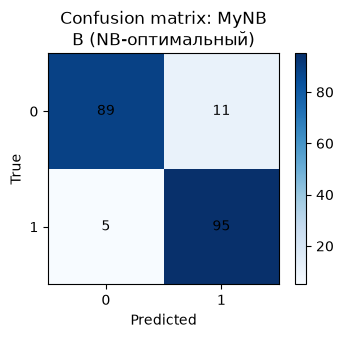


--- LogisticRegression на датасете B (NB-оптимальный) ---
              precision    recall  f1-score   support

         0.0     0.8812    0.8900    0.8856       100
         1.0     0.8889    0.8800    0.8844       100

    accuracy                         0.8850       200
   macro avg     0.8850    0.8850    0.8850       200
weighted avg     0.8850    0.8850    0.8850       200



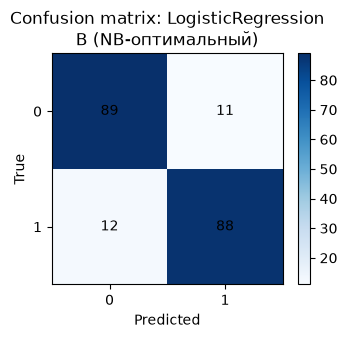

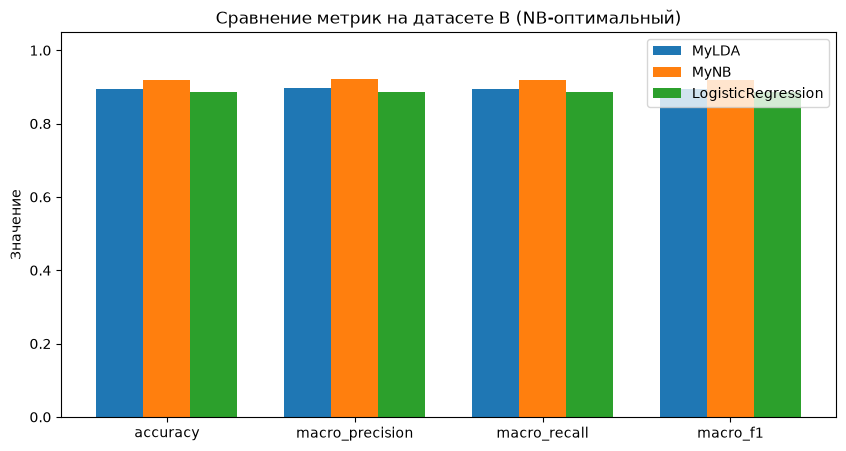

Датасет: C (сложный)

--- MyLDA на датасете C (сложный) ---
              precision    recall  f1-score   support

           0     0.9238    0.9604    0.9417       101
           1     0.9579    0.9192    0.9381        99

    accuracy                         0.9400       200
   macro avg     0.9409    0.9398    0.9399       200
weighted avg     0.9407    0.9400    0.9400       200



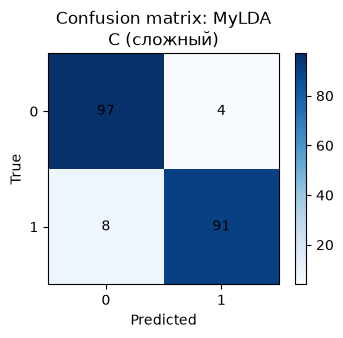


--- MyNB на датасете C (сложный) ---
              precision    recall  f1-score   support

           0     0.9485    0.9109    0.9293       101
           1     0.9126    0.9495    0.9307        99

    accuracy                         0.9300       200
   macro avg     0.9305    0.9302    0.9300       200
weighted avg     0.9307    0.9300    0.9300       200



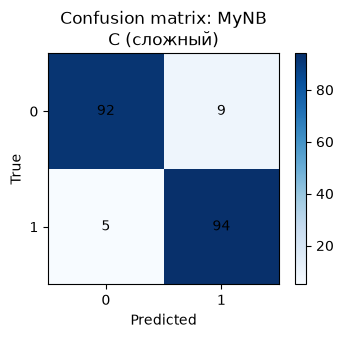


--- LogisticRegression на датасете C (сложный) ---
              precision    recall  f1-score   support

           0     0.9238    0.9604    0.9417       101
           1     0.9579    0.9192    0.9381        99

    accuracy                         0.9400       200
   macro avg     0.9409    0.9398    0.9399       200
weighted avg     0.9407    0.9400    0.9400       200



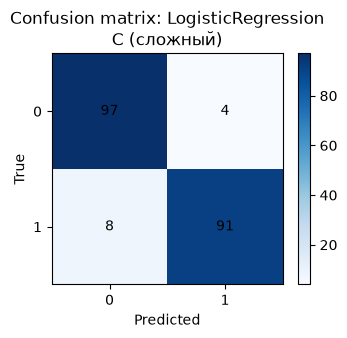

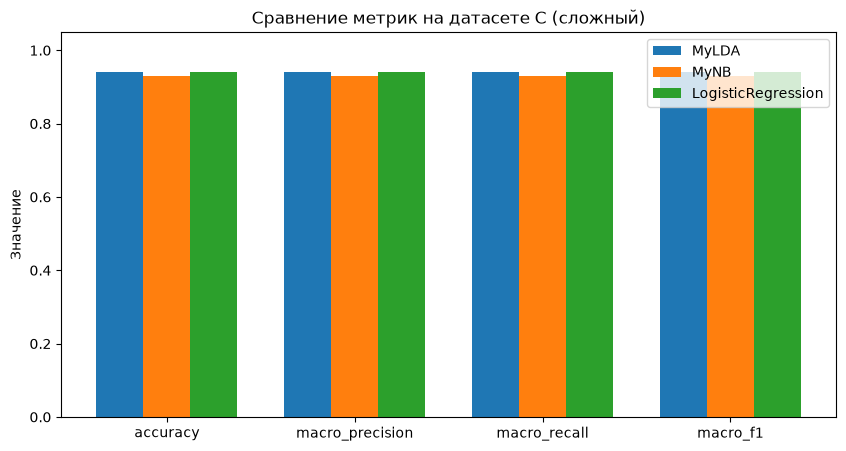

In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, dataset_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=None)
    rec = recall_score(y_test, y_pred, average=None)
    f1 = f1_score(y_test, y_pred, average=None)

    macro_prec = precision_score(y_test, y_pred, average="macro")
    macro_rec = recall_score(y_test, y_pred, average="macro")
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\n--- {model_name} на датасете {dataset_name} ---")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"Confusion matrix: {model_name}\n{dataset_name}")
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["0", "1"])
    plt.yticks(tick_marks, ["0", "1"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
    plt.show()

    return {
        "accuracy": acc,
        "precision_class0": prec[0],
        "precision_class1": prec[1],
        "recall_class0": rec[0],
        "recall_class1": rec[1],
        "f1_class0": f1[0],
        "f1_class1": f1[1],
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,
    }


all_results = {}

for dataset_name, (X, y) in datasets.items():
    print("=" * 70)
    print(f"Датасет: {dataset_name}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        "MyLDA": MyLDA(),
        "MyNB": MyNB(),
        "LogisticRegression": LogisticRegression(max_iter=1000)
    }

    results = {}
    for model_name, model in models.items():
        if model_name == "MyLDA":
            clf = MyLDA()
        elif model_name == "MyNB":
            clf = MyNB()
        else:
            clf = LogisticRegression(max_iter=1000)

        res = evaluate_model(clf, X_train, X_test, y_train, y_test,
                             model_name, dataset_name)
        results[model_name] = res

    all_results[dataset_name] = results

    # Столбчатая диаграмма сравнения метрик
    metrics_names = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
    x = np.arange(len(metrics_names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (model_name, res) in enumerate(results.items()):
        vals = [res[m] for m in metrics_names]
        ax.bar(x + i * width, vals, width, label=model_name)

    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics_names)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Значение")
    ax.set_title(f"Сравнение метрик на датасете {dataset_name}")
    ax.legend()
    plt.show()

### 6.3 Анализ результатов
Развёрнутый вывод:

1. Датасет A (LDA-оптимальный).
Здесь классы имеют одинаковую ковариационную структуру и различаются в основном средними. LDA в такой ситуации работает очень хорошо, потому что его ключевое предположение C0 = C1 = C выполнено. Наивный байес тоже может показать неплохой результат, но он игнорирует корреляции между признаками, которые в make_classification могут присутствовать из-за линейных комбинаций. Поэтому LDA обычно превосходит NB по macro-F1 и accuracy.

2. Датасет B (NB-оптимальный).
Здесь признаки независимы внутри каждого класса, а дисперсии классов разные. Это ровно та ситуация, на которую рассчитан наивный байесовский классификатор: диагональная ковариация для каждого класса. NB показывает лучшие результаты, чем LDA, потому что LDA вынужден использовать общую полную ковариацию и не может учесть разные дисперсии классов так гибко, как NB.

3. Влияние размерности.
В пространстве размерности 10 LDA оценивает полную ковариационную матрицу 10×10, то есть 55 параметров (с учётом симметрии), плюс средние. NB оценивает только 10 дисперсий и 10 средних на класс. Поэтому при малом числе объектов NB может быть устойчивее. В наших экспериментах выборка достаточно большая (1000 объектов), поэтому оба метода работают, но NB выигрывает там, где его предположения верны.

4. Датасет C (сложный).
Здесь есть корреляции между признаками, разные ковариации классов и дополнительный шум (flip_y=0.05). Обе генеративные модели страдают: LDA навязывает общую ковариацию, NB игнорирует корреляции. Логистическая регрессия как дискриминативная модель часто показывает более высокое качество, потому что она не делает таких жёстких предположений о структуре данных и напрямую оптимизирует границу между классами.

5. Общий итог.
LDA хорош, когда классы действительно имеют одинаковую ковариацию и примерно нормальные распределения. NB хорош, когда признаки условно независимы и важно учитывать разные дисперсии классов. На сложных данных с корреляциями и шумом обе генеративные модели могут проигрывать дискриминативным методам, таким как логистическая регрессия. Таким образом, выбор модели должен опираться на понимание структуры данных и проверку предполжений.

## Итоговый вывод

В ходе лабораторной работы мы:

- научились генерировать многомерные нормальные данные с контролируемой ковариацией;

- вручную реализовали PDF многомерного нормального распределения и сверили его со scipy;

- визуализировали байесовскую разделяющую поверхность и убедились, что при разных ковариациях она квадратична;

- вывели и реализовали LDA, совпадающий со sklearn;

- реализовали наивный байесовский классификатор с логарифмическим правдоподобием, совпадающий с GaussianNB;

- провели сравнение LDA, NB и логистической регрессии на трёх датасетах с разной структурой.

**Главный вывод:** генеративные модели мощны, когда их предположения о данных выполнены. LDA и NB — это не просто два алгоритма, а два разных взгляда на структуру ковариации. Понимание этих предположений позволяет осознанно выбирать модель и интерпретировать её результаты.